In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_path = "../data/processed/data_initial_audit.csv"

print("Current working directory:", os.getcwd())
print("File exists:", os.path.exists(file_path))

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Current working directory: d:\Insurance_Lapse_CLV\Insurance_Lapse_CLV\notebooks
File exists: True
Dataset shape: (50000, 16)


,customer_id,starting_date,suspension_date,observation_end_date,duration_days,event,age,income,annual_premium,has_children,marital_status,home_owner,college_degree,good_credit,county,duration_years
0,2.213007e+11,2022-09-02,2022-09-18,2022-09-18,16,1,42.806,250000.0,756.722144,1.0,Married,1.0,0.0,1.0,Tarrant,0.043806
1,2.213033e+11,2009-09-13,NaN,2022-12-02,4828,0,47.305,125000.0,875.814547,0.0,Married,1.0,1.0,1.0,Tarrant,13.218344
2,2.213023e+11,2018-02-15,NaN,2022-12-02,1751,0,41.892,70000.0,654.552197,1.0,Single,1.0,1.0,1.0,Collin,4.793977
3,2.213030e+11,2016-10-24,NaN,2022-12-02,2230,0,58.639,42500.0,795.654884,0.0,Single,1.0,0.0,1.0,Tarrant,6.105407
4,2.213006e+11,2022-06-24,2022-11-30,2022-11-30,159,1,55.444,125000.0,1142.303520,0.0,Unknown,0.0,0.0,1.0,Denton,0.435318


Event distribution:


event
0    45816
1     4184
Name: count, dtype: int64

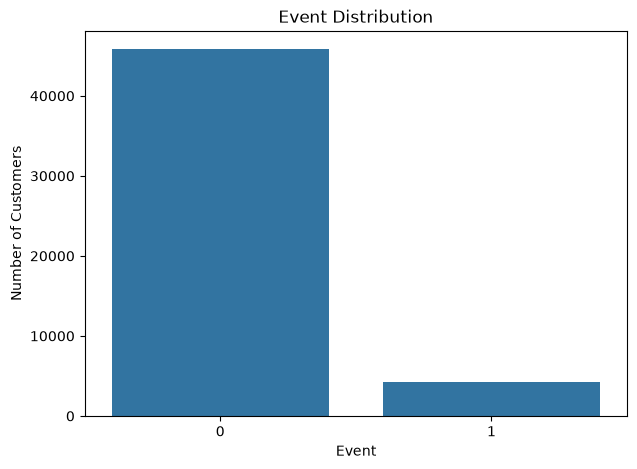

In [2]:
event_counts = df["event"].value_counts().sort_index()

print("Event distribution:")
display(event_counts)

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="event")

plt.title("Event Distribution")
plt.xlabel("Event")
plt.ylabel("Number of Customers")
plt.show()

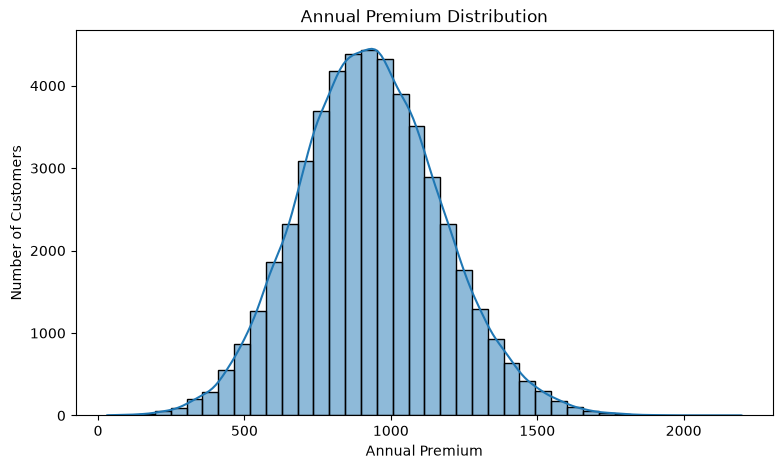

In [3]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="annual_premium",
    bins=40,
    kde=True
)

plt.title("Annual Premium Distribution")
plt.xlabel("Annual Premium")
plt.ylabel("Number of Customers")
plt.show()

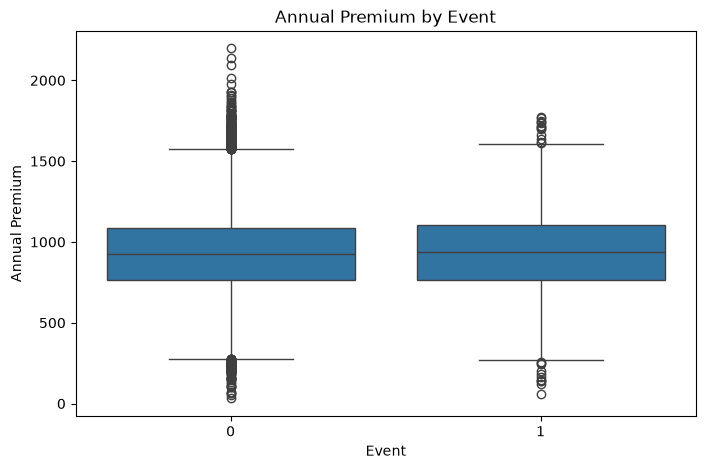

In [4]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="event",
    y="annual_premium"
)

plt.title("Annual Premium by Event")
plt.xlabel("Event")
plt.ylabel("Annual Premium")
plt.show()

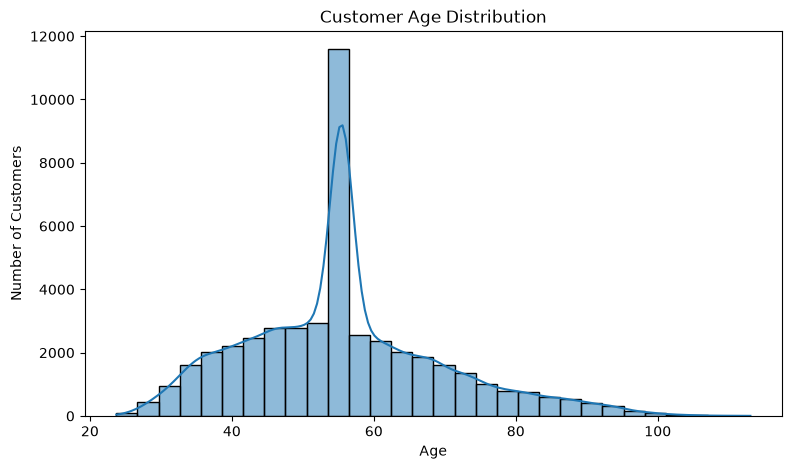

In [5]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

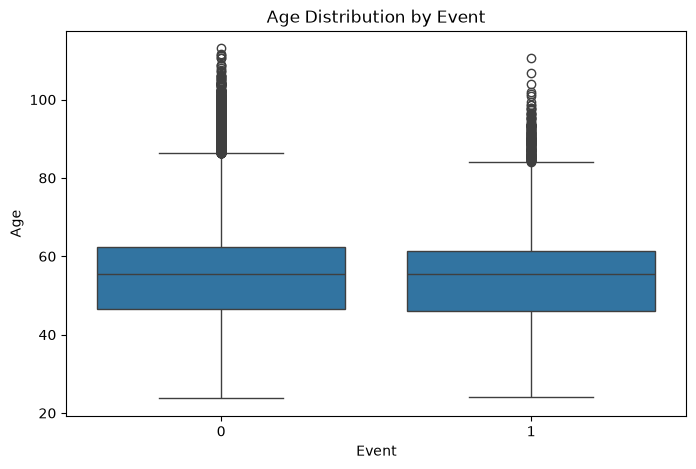

In [6]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="event",
    y="age"
)

plt.title("Age Distribution by Event")
plt.xlabel("Event")
plt.ylabel("Age")
plt.show()

In [7]:
categorical_columns = [
    "marital_status",
    "home_owner",
    "college_degree",
    "good_credit",
    "has_children"
]

for col in categorical_columns:
    print(f"\nEvent rate by {col}:")

    event_rate = (
        df.groupby(col, dropna=False)["event"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "event_rate"})
    )

    event_rate["event_rate_percent"] = (
        event_rate["event_rate"] * 100
    ).round(2)

    display(event_rate)


Event rate by marital_status:


,count,event_rate,event_rate_percent
marital_status,,,
Married,23084,0.084604,8.46
Single,13863,0.081800,8.18
Unknown,13053,0.084042,8.40



Event rate by home_owner:


,count,event_rate,event_rate_percent
home_owner,,,
0.0,13921,0.084261,8.43
1.0,32409,0.083218,8.32
NaN,3670,0.085559,8.56



Event rate by college_degree:


,count,event_rate,event_rate_percent
college_degree,,,
0.0,32327,0.085934,8.59
1.0,14003,0.077983,7.80
NaN,3670,0.085559,8.56



Event rate by good_credit:


,count,event_rate,event_rate_percent
good_credit,,,
0.0,8306,0.086323,8.63
1.0,38024,0.082921,8.29
NaN,3670,0.085559,8.56



Event rate by has_children:


,count,event_rate,event_rate_percent
has_children,,,
0.0,26122,0.081617,8.16
1.0,20208,0.086006,8.60
NaN,3670,0.085559,8.56


In [8]:
os.makedirs("../outputs/eda", exist_ok=True)

eda_summary = df.describe(include="all").T

eda_summary.to_csv("../outputs/eda/eda_summary.csv")

print("EDA summary saved successfully.")

EDA summary saved successfully.
